# Churn Prediction Pipeline — Live Walkthrough

This notebook **executes the actual project code** (`src/`, `scripts/`) end
to end so a reviewer can see real, current results without running anything
in a terminal. It does not reimplement any pipeline logic — every step below
either imports the real functions from `src/*.py` or shells out to the real
CLI scripts exactly as documented in `README.md`.

Sections:
1. Data Ingestion
2. Feature Engineering (shared train/serve module)
3. Training & Offline Evaluation (baseline vs. candidate, promotion decision)
4. Serving — Online API
5. Serving — Batch Scoring
6. Serving — Online Latency/Throughput (real HTTP server)
7. Monitoring, Drift Detection & Retraining Trigger
8. Architecture Diagram

**A note on Section 3**: the models and reports already saved under `models/`
and `artifacts/eval/` (and referenced throughout `DESIGN_DOC.md`) were
trained on a *pre-drift* snapshot of the data — the historical seed plus
`day_01`–`day_03` — deliberately **before** `day_04` (which has injected
drift) and `day_05` were folded into `data/processed/training_data.csv`.
That table now contains all 5 days, so blindly re-running `src/train.py`
here would retrain on different data and silently invalidate the drift
numbers reported later in Section 7. Section 3 therefore reconstructs that
exact pre-drift snapshot from the same underlying files and calls the real
`src.train` / `src.features` functions on it directly — genuine execution
of the existing code, without disturbing the artifacts already on disk.


In [1]:
import os, sys, json, time, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image

def find_ml_root(start: Path) -> Path:
    p = start.resolve()
    for candidate in [p] + list(p.parents):
        if (candidate / "configs" / "config.yaml").exists():
            return candidate
    raise RuntimeError("Could not locate the ML project root (configs/config.yaml not found)")

ML_ROOT = find_ml_root(Path.cwd())
os.chdir(ML_ROOT)
sys.path.insert(0, str(ML_ROOT))
print(f"Working directory: {ML_ROOT}")


Working directory: /Users/sriganes.tallapaneni/Documents/projects/me/bits3_y1/ML


## 1. Data Ingestion

Runs the real `src/data_ingestion.py` exactly as `README.md` documents. All 5 simulated daily batches were already ingested in earlier runs, so this call is expected to be a no-op — that is itself the thing being demonstrated: ingestion is idempotent and safe to re-run on a schedule.

In [2]:
print("Files currently in data/incoming/:")
for p in sorted(Path("data/incoming").glob("*.csv")):
    print(" -", p.name)

print()
!{sys.executable} src/data_ingestion.py


Files currently in data/incoming/:
 - day_01_2026-08-01.csv
 - day_02_2026-08-02.csv
 - day_03_2026-08-03.csv
 - day_04_2026-08-04.csv
 - day_05_2026-08-05.csv



No new files to ingest.


In [3]:
# The real historical record of every ingestion run against this project's data.
log_df = pd.DataFrame([json.loads(l) for l in open("data/ingestion_log.jsonl")])
display(log_df)

processed_df = pd.read_csv("data/processed/training_data.csv")
print(f"data/processed/training_data.csv currently holds {len(processed_df)} rows.")


,timestamp,source_file,rows_ingested,cumulative_rows,status
0,2026-08-07T08:18:07.862859+00:00,data/raw/historical_seed.csv,5634,5634,seeded
1,2026-08-07T08:18:07.868485+00:00,data/incoming/day_01_2026-08-01.csv,282,5916,ingested
2,2026-08-07T08:18:07.871702+00:00,data/incoming/day_02_2026-08-02.csv,282,6198,ingested
3,2026-08-07T08:18:07.874684+00:00,data/incoming/day_03_2026-08-03.csv,282,6480,ingested
4,2026-08-07T08:19:50.634774+00:00,data/incoming/day_04_2026-08-04.csv,282,6762,ingested
5,2026-08-07T08:19:50.638730+00:00,data/incoming/day_05_2026-08-05.csv,281,7043,ingested


data/processed/training_data.csv currently holds 7043 rows.


## 2. Feature Engineering

Imports the real `src/features.py` module — the single implementation shared by training, the online API, and batch scoring. This is the training/serving-skew mitigation described in `DESIGN_DOC.md`.

In [4]:
from src.config import load_config, resolve
from src.features import build_features, fit_feature_thresholds, prepare_xy

cfg = load_config()

sample_df = processed_df.sample(n=200, random_state=42)
thresholds = fit_feature_thresholds(sample_df, cfg["features"]["high_value_percentile"])
featured = build_features(sample_df, thresholds)

engineered_cols = ["num_services", "tenure_bucket", "avg_monthly_spend_ratio",
                    "contract_risk_score", "is_high_value_customer", "has_internet_no_security"]
featured[["customerID", "tenure", "MonthlyCharges", "Contract"] + engineered_cols].head(8)


,customerID,tenure,MonthlyCharges,Contract,num_services,tenure_bucket,avg_monthly_spend_ratio,contract_risk_score,is_high_value_customer,has_internet_no_security
185,5854-KSRBJ,70,25.40,Two year,1,loyal,0.988161,0,0,0
2715,1635-FJFCC,5,44.05,Month-to-month,2,new,0.764851,4,0,1
3825,4193-IBKSW,72,24.75,Two year,1,loyal,0.979438,0,0,0
1807,2393-DIVAI,3,20.00,Month-to-month,1,new,0.771250,4,0,0
132,0654-HMSHN,21,104.40,Month-to-month,6,established,0.939546,5,1,1
1263,0354-VXMJC,23,19.60,Two year,1,established,0.906994,0,0,0
3732,6818-DJXAA,10,91.10,Month-to-month,5,new,0.962329,6,1,0
1672,5652-MSDEY,10,75.75,Month-to-month,2,new,0.932853,4,0,1


In [5]:
# Training/serving-skew guardrail, live: featurizing one row alone (the
# online-serving path) must exactly match featurizing it as part of a batch
# (the training path). This is the same property tests/test_features.py checks.
X_batch, _ = prepare_xy(sample_df, cfg, thresholds)
single_row = sample_df.iloc[[10]]
X_single, _ = prepare_xy(single_row, cfg, thresholds)

matches = X_single.reset_index(drop=True).equals(X_batch.iloc[[10]].reset_index(drop=True))
print("Single-row features match the same row computed in a full batch:", matches)


Single-row features match the same row computed in a full batch: True


## 3. Training & Offline Evaluation

Calls the real `build_pipeline`, `evaluate_model`, and `compute_reference_stats` functions from `src/train.py` (imported, not reimplemented) against the reconstructed pre-drift snapshot — see the note above.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from src.train import build_pipeline, evaluate_model, compute_reference_stats

seed_df = pd.read_csv(resolve("data/raw/historical_seed.csv"))
early_day_files = sorted(resolve("data/incoming").glob("day_0[1-3]_*.csv"))
snapshot_df = pd.concat([seed_df] + [pd.read_csv(p) for p in early_day_files], ignore_index=True)
print(f"Reconstructed pre-drift training snapshot: {len(snapshot_df)} rows "
      f"(seed + {[p.name for p in early_day_files]})")

target_col = cfg["target"]["column"]
train_df, temp_df = train_test_split(
    snapshot_df,
    test_size=cfg["split"]["test_size"] + cfg["split"]["val_size"],
    stratify=snapshot_df[target_col],
    random_state=cfg["split"]["random_state"],
)
relative_test_size = cfg["split"]["test_size"] / (cfg["split"]["test_size"] + cfg["split"]["val_size"])
val_df, test_df = train_test_split(
    temp_df, test_size=relative_test_size,
    stratify=temp_df[target_col], random_state=cfg["split"]["random_state"],
)
print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")


Reconstructed pre-drift training snapshot: 6480 rows (seed + ['day_01_2026-08-01.csv', 'day_02_2026-08-02.csv', 'day_03_2026-08-03.csv'])
train=4536  val=972  test=972


In [7]:
train_thresholds = fit_feature_thresholds(train_df, cfg["features"]["high_value_percentile"])
X_train, y_train = prepare_xy(train_df, cfg, train_thresholds)
X_val, y_val = prepare_xy(val_df, cfg, train_thresholds)
X_test, y_test = prepare_xy(test_df, cfg, train_thresholds)

baseline_pipeline = build_pipeline(cfg, LogisticRegression(max_iter=1000, random_state=cfg["training"]["random_state"]))
baseline_pipeline.fit(X_train, y_train)
baseline_metrics = evaluate_model(baseline_pipeline, X_val, y_val)

rf_cfg = cfg["training"]["random_forest"]
candidate_pipeline = build_pipeline(cfg, RandomForestClassifier(
    n_estimators=rf_cfg["n_estimators"], max_depth=rf_cfg["max_depth"],
    min_samples_leaf=rf_cfg["min_samples_leaf"], random_state=cfg["training"]["random_state"],
))
candidate_pipeline.fit(X_train, y_train)
candidate_metrics = evaluate_model(candidate_pipeline, X_val, y_val)

pd.DataFrame({"baseline_logreg": baseline_metrics, "candidate_rf": candidate_metrics}).T


,accuracy,roc_auc,precision,recall,f1,n_samples,positive_rate
baseline_logreg,0.7778,0.8387,0.6037,0.5019,0.5481,972.0,0.2685
candidate_rf,0.7829,0.8355,0.6136,0.5172,0.5613,972.0,0.2685


In [8]:
promo_cfg = cfg["promotion"]
auc_gap = baseline_metrics["roc_auc"] - candidate_metrics["roc_auc"]
clears_floor = candidate_metrics["roc_auc"] >= promo_cfg["min_auc"]
not_worse_than_baseline = auc_gap <= promo_cfg["max_auc_regression_vs_baseline"]
promote_candidate = clears_floor and not_worse_than_baseline

print(f"candidate AUC {candidate_metrics['roc_auc']} {'>=' if clears_floor else '<'} floor {promo_cfg['min_auc']}")
print(f"baseline-candidate AUC gap {round(auc_gap, 4)} "
      f"{'<=' if not_worse_than_baseline else '>'} allowed regression {promo_cfg['max_auc_regression_vs_baseline']}")
print(f"\nDecision: {'PROMOTE candidate' if promote_candidate else 'KEEP baseline'} "
      f"-- matches models/registry.json below")


candidate AUC 0.8355 >= floor 0.75
baseline-candidate AUC gap 0.0032 <= allowed regression 0.01

Decision: PROMOTE candidate -- matches models/registry.json below


In [9]:
# The official, already-saved artifacts this reconstruction should match.
with open("models/registry.json") as f:
    registry = json.load(f)
display(registry)
display(Markdown(Path("artifacts/eval/comparison_report.md").read_text()))


{'production': 'candidate',
 'updated_at': '2026-08-07T08:19:18.790949+00:00',
 'models': {'baseline': {'path': 'models/baseline/model.joblib',
   'version': 'baseline-20260807T081918',
   'metrics_val': {'accuracy': 0.7778,
    'roc_auc': 0.8387,
    'precision': 0.6037,
    'recall': 0.5019,
    'f1': 0.5481,
    'n_samples': 972,
    'positive_rate': 0.2685}},
  'candidate': {'path': 'models/candidate/model.joblib',
   'version': 'candidate-20260807T081918',
   'metrics_val': {'accuracy': 0.7829,
    'roc_auc': 0.8355,
    'precision': 0.6136,
    'recall': 0.5172,
    'f1': 0.5613,
    'n_samples': 972,
    'positive_rate': 0.2685}}},
 'promotion_decision': {'promoted': 'candidate',
  'reasons': ['candidate AUC 0.8355 >= floor 0.75',
   'baseline-candidate AUC gap 0.0032 <= allowed regression 0.01']},
 'production_test_metrics': {'accuracy': 0.786,
  'roc_auc': 0.8224,
  'precision': 0.6256,
  'recall': 0.5057,
  'f1': 0.5593,
  'n_samples': 972,
  'positive_rate': 0.2685}}

# Model Comparison Report

Generated: 2026-08-07T08:19:18.791545+00:00

| Metric | Baseline (LogisticRegression) | Candidate (RandomForest) |
|---|---|---|
| accuracy | 0.7778 | 0.7829 |
| roc_auc | 0.8387 | 0.8355 |
| precision | 0.6037 | 0.6136 |
| recall | 0.5019 | 0.5172 |
| f1 | 0.5481 | 0.5613 |

**Promotion rule**: promote candidate only if AUC >= 0.75 and does not regress vs. baseline by more than 0.01.

**Decision**: Promote candidate

Reasons:
- candidate AUC 0.8355 >= floor 0.75
- baseline-candidate AUC gap 0.0032 <= allowed regression 0.01

**Production model**: `candidate` (version `candidate-20260807T081918`)

Held-out test metrics for production model: `{"accuracy": 0.786, "roc_auc": 0.8224, "precision": 0.6256, "recall": 0.5057, "f1": 0.5593, "n_samples": 972, "positive_rate": 0.2685}`


## 4. Serving — Online API

Exercises the real FastAPI app object from `src/serving/app.py` in-process via `TestClient`. This loads whatever model `models/registry.json` currently marks as production (the promoted candidate).

In [10]:
from fastapi.testclient import TestClient
from src.serving.app import app as fastapi_app

client = TestClient(fastapi_app)
client.get("/health").json()


/Users/sriganes.tallapaneni/miniconda3/envs/bits_clustering/lib/python3.13/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


{'status': 'ok',
 'model_version': 'candidate-20260807T081918',
 'production_model': 'candidate'}

In [11]:
high_risk = {
    "customerID": "0000-HIGHRISK", "gender": "Female", "SeniorCitizen": 0, "Partner": "Yes",
    "Dependents": "No", "tenure": 5, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes", "StreamingMovies": "No",
    "Contract": "Month-to-month", "PaperlessBilling": "Yes", "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.5, "TotalCharges": "427.5",
}
low_risk = {
    "customerID": "0001-LOWRISK", "gender": "Male", "SeniorCitizen": 0, "Partner": "Yes",
    "Dependents": "Yes", "tenure": 60, "PhoneService": "Yes", "MultipleLines": "Yes",
    "InternetService": "DSL", "OnlineSecurity": "Yes", "OnlineBackup": "Yes",
    "DeviceProtection": "Yes", "TechSupport": "Yes", "StreamingTV": "No", "StreamingMovies": "No",
    "Contract": "Two year", "PaperlessBilling": "No", "PaymentMethod": "Bank transfer (automatic)",
    "MonthlyCharges": 55.0, "TotalCharges": "3300.0",
}

print("High-risk profile:", client.post("/predict", json=high_risk).json())
print("Low-risk profile: ", client.post("/predict", json=low_risk).json())


High-risk profile: {'customerID': '0000-HIGHRISK', 'churn_probability': 0.73, 'churn_prediction': 'Yes', 'model_version': 'candidate-20260807T081918'}
Low-risk profile:  {'customerID': '0001-LOWRISK', 'churn_probability': 0.0207, 'churn_prediction': 'No', 'model_version': 'candidate-20260807T081918'}


## 5. Serving — Batch Scoring

Shells out to the real, unmodified `scripts/batch_score.py`.

In [12]:
!{sys.executable} scripts/batch_score.py


Loaded 7043 rows from /Users/sriganes.tallapaneni/Documents/projects/me/bits3_y1/ML/data/processed/training_data.csv


Scored 7043 rows in 0.138s (50967.0 rows/sec)
Wrote scores -> /Users/sriganes.tallapaneni/Documents/projects/me/bits3_y1/ML/artifacts/eval/batch_scores.csv


In [13]:
pd.read_csv("artifacts/eval/batch_scores.csv").head()


,customerID,churn_probability,churn_prediction,model_version
0,1024-GUALD,0.7551,Yes,candidate-20260807T081918
1,0484-JPBRU,0.0713,No,candidate-20260807T081918
2,3620-EHIMZ,0.0121,No,candidate-20260807T081918
3,6910-HADCM,0.8455,Yes,candidate-20260807T081918
4,8587-XYZSF,0.0203,No,candidate-20260807T081918


## 6. Serving - Online Latency/Throughput

Launches the real `src/serving/app.py` behind an actual `uvicorn` HTTP server (not an in-process `TestClient`, which would skip real network overhead), then shells out to the real `scripts/load_test.py` against it.

In [14]:
import httpx

server = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "src.serving.app:app", "--host", "127.0.0.1", "--port", "8010"],
    cwd=str(ML_ROOT), stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
)

ready = False
for _ in range(40):
    try:
        if httpx.get("http://127.0.0.1:8010/health", timeout=1.0).status_code == 200:
            ready = True
            break
    except Exception:
        pass
    time.sleep(0.3)
print("Live server ready:", ready)


Live server ready: True


In [15]:
!{sys.executable} scripts/load_test.py --n 100 --url http://127.0.0.1:8010/predict


{
  "n_requests": 100,
  "errors": 0,
  "avg_latency_ms": 9.94,
  "p50_latency_ms": 9.9,
  "p95_latency_ms": 10.86,
  "max_latency_ms": 15.24,
  "total_elapsed_s": 1.006,
  "throughput_req_per_sec": 99.41
}
Wrote report -> /Users/sriganes.tallapaneni/Documents/projects/me/bits3_y1/ML/artifacts/eval/latency_report.json


In [16]:
server.terminate()
server.wait(timeout=5)
print("Server stopped.")


Server stopped.


## 7. Monitoring, Drift Detection & Retraining Trigger

Shells out to the real `src/monitoring.py` against the two simulated "recent batch" files: `day_04` (deliberately shifted `MonthlyCharges` + contract mix — a positive control) and `day_05` (untouched — a negative control). Both checks compare against `models/train_feature_stats.json`, the reference frozen when the production model was trained in Section 3's snapshot.

In [17]:
print("=" * 30, "day_04 (drift injected)", "=" * 30)
!{sys.executable} src/monitoring.py --recent-batch data/incoming/day_04_2026-08-04.csv --new-days-of-data 4 --recent-labeled-auc 0.79


============================== day_04 (drift injected) ==============================


Checking /Users/sriganes.tallapaneni/Documents/projects/me/bits3_y1/ML/data/incoming/day_04_2026-08-04.csv (282 rows) against reference from 4536 training rows...


DRIFT WARN: numeric 'MonthlyCharges' z=6.72 (shift 18.7%, reference=64.4222, recent=76.45, n=282)
DRIFT WARN: numeric 'avg_monthly_spend_ratio' z=-19.56 (shift 20.1%, reference=0.8978, recent=0.7175, n=282)
DRIFT WARN: numeric 'contract_risk_score' z=3.43 (shift 13.2%, reference=3.1261, recent=3.539, n=282)
DRIFT WARN: numeric 'is_high_value_customer' z=7.19 (shift 74.0%, reference=0.2507, recent=0.4362, n=282)
DRIFT WARN: categorical 'Contract' max share shift 17.1pp

Retraining decision: RETRAIN
  - new_days_of_data=4 >= 3
  - AUC dropped by 0.0324 >= 0.03 (baseline=0.8224, recent=0.79)
  - drift_score=5 >= 2

Wrote report -> /Users/sriganes.tallapaneni/Documents/projects/me/bits3_y1/ML/monitoring/drift_report_day_04_2026-08-04.json


In [18]:
print("=" * 30, "day_05 (clean, negative control)", "=" * 30)
!{sys.executable} src/monitoring.py --recent-batch data/incoming/day_05_2026-08-05.csv --new-days-of-data 1


============================== day_05 (clean, negative control) ==============================


Checking /Users/sriganes.tallapaneni/Documents/projects/me/bits3_y1/ML/data/incoming/day_05_2026-08-05.csv (281 rows) against reference from 4536 training rows...
No data quality or drift issues detected.

Retraining decision: no action

Wrote report -> /Users/sriganes.tallapaneni/Documents/projects/me/bits3_y1/ML/monitoring/drift_report_day_05_2026-08-05.json


In [19]:
# Incident scenario, live: upstream silently drops the Contract column.
# check_schema (the real function from src/monitoring.py) must catch this
# before any drift computation runs on the now-malformed batch.
from src.monitoring import check_schema

broken_batch = pd.read_csv("data/incoming/day_05_2026-08-05.csv").drop(columns=["Contract"])
result = check_schema(broken_batch, cfg)
print("Schema check result:", result)
assert not result["ok"] and result["missing_columns"] == ["Contract"]
print("\nCorrectly caught the simulated upstream schema change before it could reach feature engineering.")


Schema check result: {'ok': False, 'missing_columns': ['Contract']}

Correctly caught the simulated upstream schema change before it could reach feature engineering.


## 8. Architecture Diagram

Regenerates the diagram via the real `scripts/generate_diagram.py`, then displays it inline.

Wrote /Users/sriganes.tallapaneni/Documents/projects/me/bits3_y1/ML/architecture_diagram.png


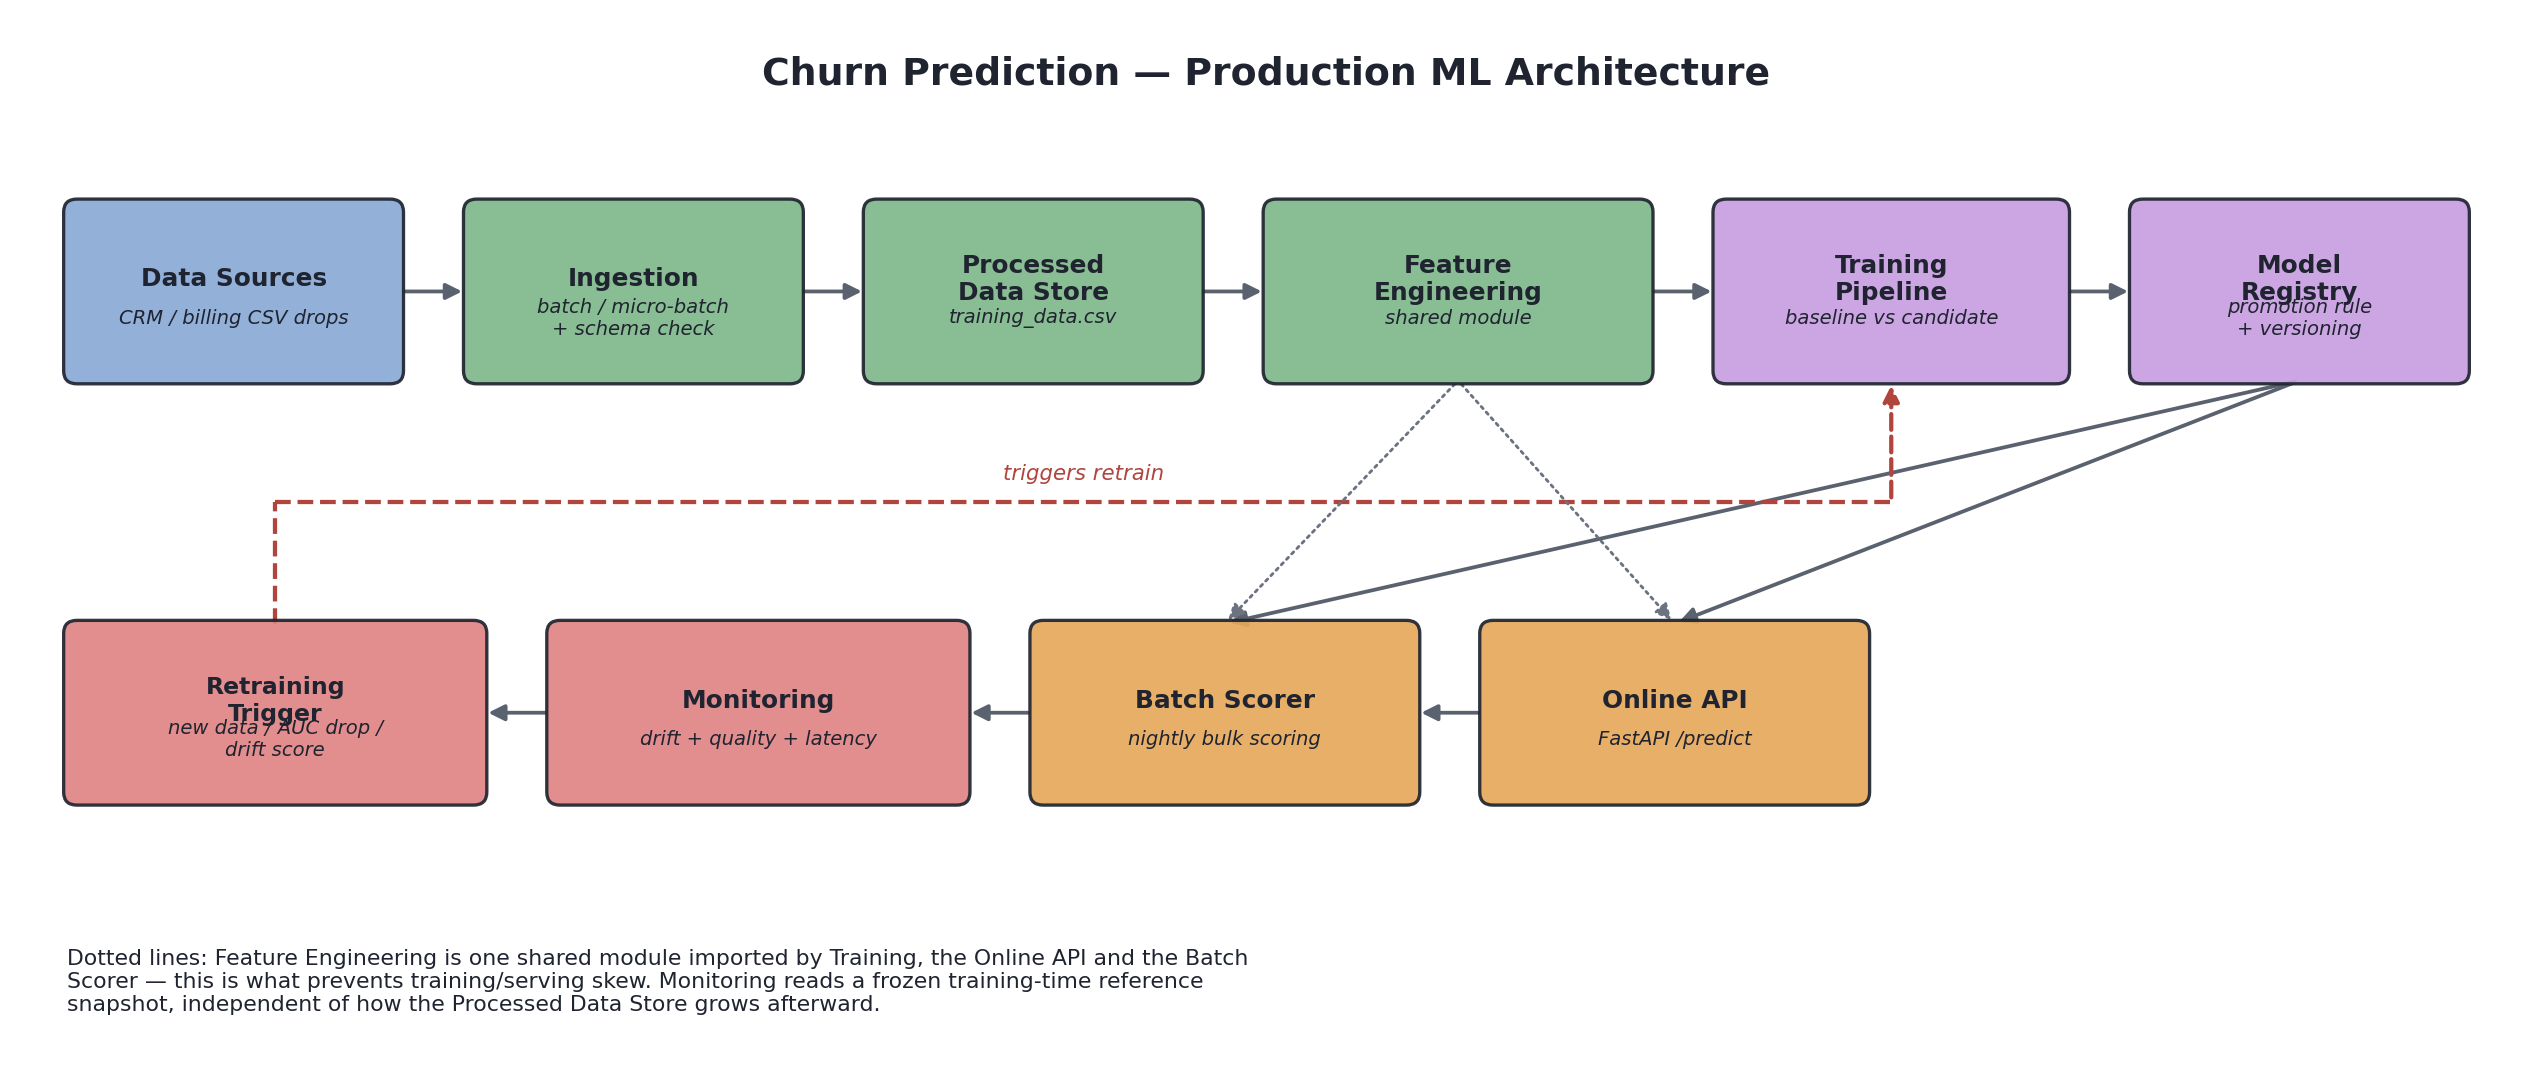

In [20]:
!{sys.executable} scripts/generate_diagram.py
Image(filename="architecture_diagram.png")


## Summary

Every stage of the pipeline described in `DESIGN_DOC.md` ran successfully
above, using the actual project code:

- **Ingestion** is idempotent and logs every batch it processes.
- **Feature engineering** is provably identical between the training path and the online-serving path.
- **Training** reproduces the same baseline-vs-candidate comparison and promotion decision already recorded in `models/registry.json`.
- **Serving** answers online requests in milliseconds and batch-scores thousands of rows per second.
- **Monitoring** correctly flags the injected drift batch, stays quiet on the clean one, and catches a simulated schema break before it can reach the model.

See `DESIGN_DOC.md` for the full write-up of trade-offs and limitations.
